# Initialisation: FitzHugh-Nagumo



Forward-mode
num = 1 | elapsed = 0.00 | max_time = 0.25
num = 2 | elapsed = 0.02 | max_time = 0.25
num = 3 | elapsed = 0.02 | max_time = 0.25
num = 4 | elapsed = 0.02 | max_time = 0.25
num = 5 | elapsed = 0.04 | max_time = 0.25
num = 6 | elapsed = 0.06 | max_time = 0.25


num = 7 | elapsed = 0.10 | max_time = 0.25


num = 8 | elapsed = 0.29 | max_time = 0.25


Taylor-mode (scan)
num = 1 | elapsed = 0.00 | max_time = 0.25
num = 2 | elapsed = 0.01 | max_time = 0.25
num = 3 | elapsed = 0.03 | max_time = 0.25
num = 4 | elapsed = 0.06 | max_time = 0.25
num = 5 | elapsed = 0.07 | max_time = 0.25


num = 6 | elapsed = 0.08 | max_time = 0.25
num = 7 | elapsed = 0.10 | max_time = 0.25
num = 8 | elapsed = 0.12 | max_time = 0.25


num = 9 | elapsed = 0.14 | max_time = 0.25
num = 10 | elapsed = 0.18 | max_time = 0.25


...

num = 7 | elapsed = 0.09 | max_time = 0.25
num = 8 | elapsed = 0.12 | max_time = 0.25


num = 9 | elapsed = 0.16 | max_time = 0.25
num = 10 | elapsed = 0.20 | max_time = 0.25


num = 11 | elapsed = 0.39 | max_time = 0.25


Taylor-mode (doubling)
num = 1 | elapsed = 0.00 | max_time = 0.25
num = 2 | elapsed = 0.06 | max_time = 0.25


num = 3 | elapsed = 0.22 | max_time = 0.25


num = 4 | elapsed = 1.21 | max_time = 0.25


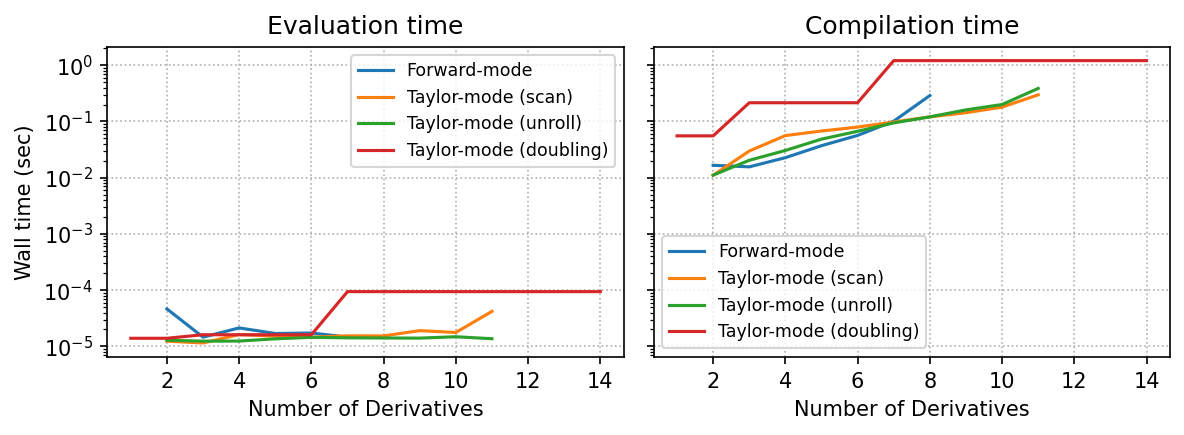

In [1]:
"""Benchmark the initialisation methods on the FitzHugh-Nagumo problem."""

import functools
import statistics
import time
import timeit
from collections.abc import Callable

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from probdiffeq import taylor

# Fail this notebook on NaN detection (to catch those in the CI)
jax.config.update("jax_debug_nans", True)


def main(max_time=0.25, repeats=2) -> None:
    """Run the script."""
    # Set JAX config
    jax.config.update("jax_enable_x64", True)

    algorithms = {
        r"Forward-mode": odejet_via_jvp(),
        r"Taylor-mode (scan)": taylor_mode_scan(),
        r"Taylor-mode (unroll)": taylor_mode_unroll(),
        r"Taylor-mode (doubling)": taylor_mode_doubling(),
    }

    # Compute a reference solution
    timeit_fun = timeit_fun_from_args(repeats=repeats)

    # Compute all work-precision diagrams
    results = {}
    for label, algo in algorithms.items():
        print("\n")
        print(label)
        results[label] = adaptive_benchmark(
            algo, timeit_fun=timeit_fun, max_time=max_time
        )

    _fig, (axis_perform, axis_compile) = plt.subplots(
        ncols=2, figsize=(8, 3), dpi=150, sharex=True, sharey=True
    )

    for label, wp in results.items():
        inputs = wp["arguments"]
        work_compile = wp["work_compile"]
        work_mean, work_std = wp["work_mean"], wp["work_std"]

        if "doubling" in label:
            num_repeats = jnp.diff(jnp.concatenate((jnp.ones((1,)), inputs)))
            inputs = jnp.arange(1, jnp.amax(inputs) * 1)
            work_compile = _adaptive_repeat(work_compile, num_repeats)
            work_mean = _adaptive_repeat(work_mean, num_repeats)
            work_std = _adaptive_repeat(work_std, num_repeats)

        axis_compile.semilogy(inputs, work_compile, label=label)
        axis_perform.semilogy(inputs, work_mean, label=label)

    axis_compile.set_title("Compilation time")
    axis_perform.set_title("Evaluation time")
    axis_perform.legend(fontsize="small")
    axis_compile.legend(fontsize="small")
    axis_compile.set_xlabel("Number of Derivatives")
    axis_perform.set_xlabel("Number of Derivatives")
    axis_perform.set_ylabel("Wall time (sec)")
    axis_perform.grid(linestyle="dotted")
    axis_compile.grid(linestyle="dotted")

    plt.tight_layout()
    plt.show()


def _adaptive_repeat(xs, ys):
    """Repeat the doubling values correctly to create a comprehensible plot."""
    zs = []
    for x, y in zip(xs, ys):
        zs.extend([x] * int(y))
    return jnp.asarray(zs)


def timeit_fun_from_args(*, repeats: int) -> Callable:
    """Construct a timeit-function from the command-line arguments."""

    def timer(fun, /):
        return list(timeit.repeat(fun, number=1, repeat=repeats))

    return timer


def taylor_mode_scan() -> Callable:
    """Taylor-mode estimation."""
    vf_auto, (u0,) = _fitzhugh_nagumo()

    @functools.partial(jax.jit, static_argnames=["num"])
    def estimate(num):
        tcoeffs = taylor.odejet_padded_scan(vf_auto, (u0,), num=num)
        return jnp.asarray(tcoeffs)

    return estimate


def taylor_mode_unroll() -> Callable:
    """Taylor-mode estimation."""
    vf_auto, (u0,) = _fitzhugh_nagumo()

    @functools.partial(jax.jit, static_argnames=["num"])
    def estimate(num):
        tcoeffs = taylor.odejet_unroll(vf_auto, (u0,), num=num)
        return jnp.asarray(tcoeffs)

    return estimate


def taylor_mode_doubling() -> Callable:
    """Taylor-mode estimation."""
    vf_auto, (u0,) = _fitzhugh_nagumo()

    @functools.partial(jax.jit, static_argnames=["num"])
    def estimate(num):
        tcoeffs = taylor.odejet_doubling_unroll(vf_auto, (u0,), num_doublings=num)
        return jnp.asarray(tcoeffs)

    return estimate


def odejet_via_jvp() -> Callable:
    """Forward-mode estimation."""
    vf_auto, (u0,) = _fitzhugh_nagumo()

    @functools.partial(jax.jit, static_argnames=["num"])
    def estimate(num):
        tcoeffs = taylor.odejet_via_jvp(vf_auto, (u0,), num=num)
        return jnp.asarray(tcoeffs)

    return estimate


def _fitzhugh_nagumo():
    u0 = jnp.asarray([-1.0, 1.0])

    @jax.jit
    def vf_probdiffeq(u, a=0.2, b=0.2, c=3.0):
        """FitzHugh--Nagumo model."""
        du1 = c * (u[0] - u[0] ** 3 / 3 + u[1])
        du2 = -(1.0 / c) * (u[0] - a - b * u[1])
        return jnp.asarray([du1, du2])

    return vf_probdiffeq, (u0,)


def adaptive_benchmark(fun, *, timeit_fun: Callable, max_time) -> dict:
    """Benchmark a function iteratively until a max-time threshold is exceeded."""
    work_compile = []
    work_mean = []
    work_std = []
    arguments = []

    t0 = time.perf_counter()
    arg = 1
    while (elapsed := time.perf_counter() - t0) < max_time:
        print(f"num = {arg} | elapsed = {elapsed:.2f} | max_time = {max_time}")
        t0 = time.perf_counter()
        tcoeffs = fun(arg).block_until_ready()
        t1 = time.perf_counter()
        time_compile = t1 - t0

        time_execute = timeit_fun(lambda: fun(arg).block_until_ready())  # noqa: B023

        arguments.append(len(tcoeffs))
        work_compile.append(time_compile)
        work_mean.append(statistics.mean(time_execute))
        work_std.append(statistics.stdev(time_execute))
        arg += 1
    print(f"num = {arg} | elapsed = {elapsed:.2f} | max_time = {max_time}")
    return {
        "work_mean": jnp.asarray(work_mean),
        "work_std": jnp.asarray(work_std),
        "work_compile": jnp.asarray(work_compile),
        "arguments": jnp.asarray(arguments),
    }


main()